# Hemanth-NLP EDA 



### Overview:
- This notebook displays our team's EDA into three main parts:
  - NLP EDA(Stream A)


In [ ]:
import sys
import pandas as pd
from google.colab import drive
import importlib

drive.mount('/content/drive')

# Using the Cleaned V1 dataset as per the team contract
DATA_PATH = '/content/drive/MyDrive/DTSC 5082- Group 12 - Guardian Recruit/data/preprocessed/train_clean_v1.csv'
df = pd.read_csv(DATA_PATH)

print(f"Loaded Cleaned Train V1: {df.shape}")
# Confirming Contract: Binary columns should be 0/1
print(df[['fraudulent', 'has_company_logo']].head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded Cleaned Train V1: (8696, 20)
   fraudulent  has_company_logo
0           0                 1
1           0                 0
2           0                 1
3           0                 1
4           0                 1


In [ ]:
df.head()


,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,in_balanced_dataset,country,desc_len
0,Inside Sales Consultant B2B software company,"US, GA, Atlanta",Sales,35000-150000,<p>Katapult Group - We leverage technology and...,<p>Katapult Group is a global business buildin...,<p>Although this product converts extremly hig...,<p><b>Compensation:</b> 3000-5000$ per month p...,0,1,1,Full-time,Entry level,Certification,Internet,Sales,0,0,US,1907
1,Cad Designer,"US, OH, Cleveland",NaN,NaN,<p>We Provide Full Time Permanent Positions fo...,<p><b><i>(We have more than 1500 Job openings ...,Unspecified,Unspecified,0,0,0,Full-time,NaN,NaN,NaN,NaN,0,0,US,2505
2,Micro-grid Systems Engineer,"US, CA, Santa Monica",tech,NaN,<p>hello world</p>\r\n<p>talents23_ drives the...,<p>We have extensive experience in battery sto...,<ul>\r\n<li>Experience with utility interactiv...,"<p>Want to be part of a fast growing, high ene...",0,1,1,Full-time,NaN,NaN,NaN,NaN,0,0,US,699
3,Software Engineer,"US, NY, Brooklyn",Engineering,NaN,<p>Maker’s Row is an online marketplace that c...,<p>Our Engineering team values software qualit...,<ul>\r\n<li>3+ years of full-stack development...,<ul>\r\n<li>Healthcare</li>\r\n</ul><ul>\r\n<l...,0,1,1,Full-time,Associate,Bachelor's Degree,Computer Software,Engineering,0,0,US,1162
4,Messenger Courier - Part Time,"US, DC, Washington",NaN,NaN,"<p>Novitex Enterprise Solutions, formerly Pitn...",<p>The Messenger Courier will be based in our ...,<p><b>Minimum Requirements:</b></p>\r\n<ul>\r\...,Unspecified,0,1,0,Part-time,Entry level,High School or equivalent,Government Administration,Customer Service,0,0,US,1489


In [ ]:
df.columns.tolist()

['title',
 'location',
 'department',
 'salary_range',
 'company_profile',
 'description',
 'requirements',
 'benefits',
 'telecommuting',
 'has_company_logo',
 'has_questions',
 'employment_type',
 'required_experience',
 'required_education',
 'industry',
 'function',
 'fraudulent',
 'in_balanced_dataset',
 'country',
 'desc_len']

In [ ]:
import re

def clean_text(text):
    text = str(text)
    text = re.sub('<.*?>', ' ', text)   # remove HTML tags
    text = re.sub('[^a-zA-Z ]', ' ', text)  # keep letters only
    text = text.lower()
    return text

df['clean_description'] = df['description'].apply(clean_text)

In [ ]:
df[['description','clean_description']].head()

,description,clean_description
0,<p>Katapult Group is a global business buildin...,katapult group is a global business building ...
1,<p><b><i>(We have more than 1500 Job openings ...,we have more than job openings in our...
2,<p>We have extensive experience in battery sto...,we have extensive experience in battery stora...
3,<p>Our Engineering team values software qualit...,our engineering team values software quality ...
4,<p>The Messenger Courier will be based in our ...,the messenger courier will be based in our wa...


In [ ]:
df['clean_desc_len'] = df['clean_description'].apply(len)

In [ ]:
df[['clean_description','clean_desc_len']].head()

,clean_description,clean_desc_len
0,katapult group is a global business building ...,1783
1,we have more than job openings in our...,2392
2,we have extensive experience in battery stora...,661
3,our engineering team values software quality ...,1112
4,the messenger courier will be based in our wa...,1327


In [ ]:
df.groupby('fraudulent')['clean_desc_len'].mean()

,clean_desc_len
fraudulent,
0,1310.965796
1,1261.658768


In [ ]:
df.isnull().sum()

,0
title,0
location,171
department,5602
salary_range,7301
company_profile,0
description,0
requirements,0
benefits,0
telecommuting,0
has_company_logo,0


In [ ]:
df['fraudulent'].value_counts()

,count
fraudulent,
0,8274
1,422


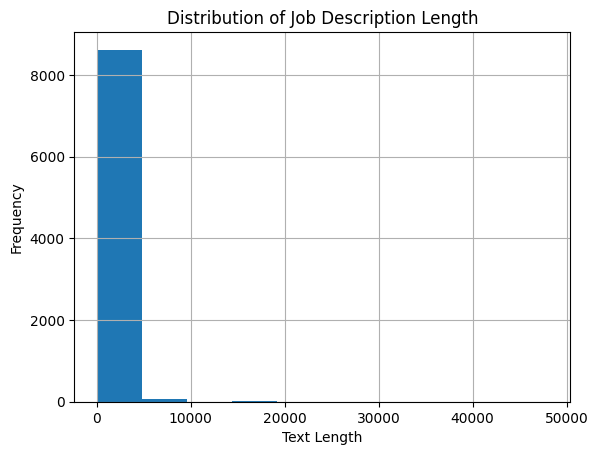

In [ ]:
import matplotlib.pyplot as plt

df['clean_desc_len'].hist()
plt.title("Distribution of Job Description Length")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()

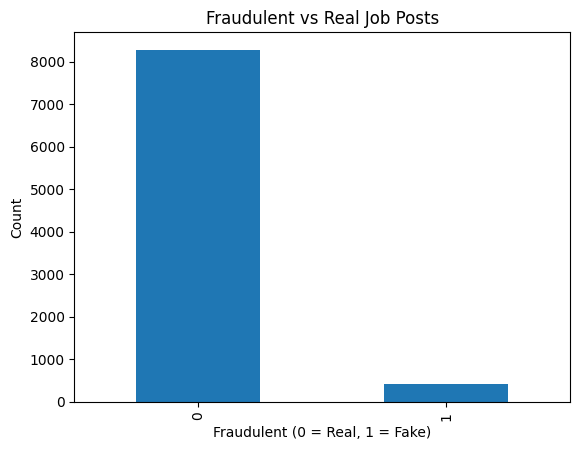

In [ ]:
df['fraudulent'].value_counts().plot(kind='bar')

plt.title("Fraudulent vs Real Job Posts")
plt.xlabel("Fraudulent (0 = Real, 1 = Fake)")
plt.ylabel("Count")
plt.show()

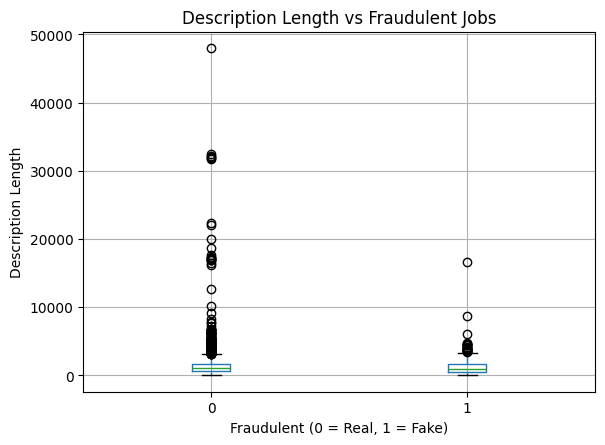

In [ ]:
df.boxplot(column='clean_desc_len', by='fraudulent')

plt.title("Description Length vs Fraudulent Jobs")
plt.suptitle("")
plt.xlabel("Fraudulent (0 = Real, 1 = Fake)")
plt.ylabel("Description Length")
plt.show()

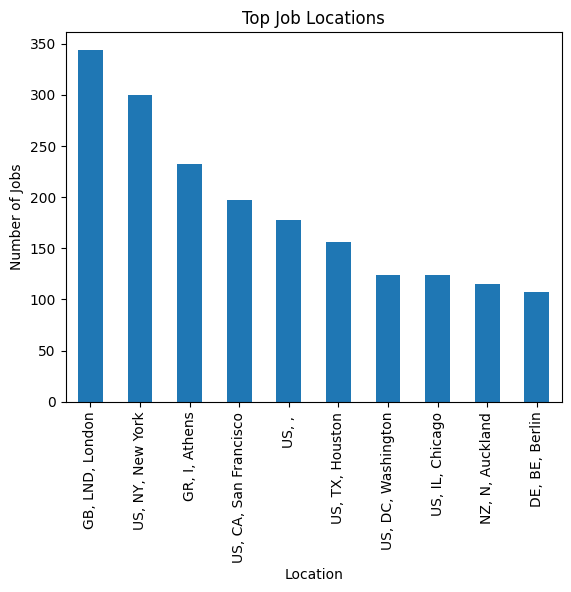

In [ ]:
df['location'].value_counts().head(10).plot(kind='bar')

plt.title("Top Job Locations")
plt.xlabel("Location")
plt.ylabel("Number of Jobs")
plt.show()

In [ ]:
df.describe()

,telecommuting,has_company_logo,has_questions,fraudulent,in_balanced_dataset,desc_len,clean_desc_len
count,8696.000000,8696.000000,8696.000000,8696.000000,8696.000000,8696.000000,8696.000000
mean,0.040133,0.790363,0.496320,0.048528,0.051633,1433.579692,1308.573022
std,0.196283,0.407073,0.500015,0.214892,0.221298,1724.195520,1461.897347
min,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,5.000000
25%,0.000000,1.000000,0.000000,0.000000,0.000000,662.000000,614.000000
50%,0.000000,1.000000,0.000000,0.000000,0.000000,1146.500000,1046.500000
75%,0.000000,1.000000,1.000000,0.000000,0.000000,1774.250000,1649.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,55130.000000,48005.000000
